# NumpyDataset: загрузка EEG/EOG через MNE

## Goal

Показать второй этап реализации датасета: ленивую загрузку одной пары EEG/EOG FIF в NumPy. Ноутбук демонстрирует:

- integer и tuple indexing;
- структуру `LoadedSample`;
- формы, каналы, частоту и dtype массивов;
- фильтрацию geometric/random;
- разницу памяти между `float32` и `float64`.

## Setup

Используем `data/Data_Train`. На текущем этапе каждый вызов `dataset[...]` читает FIF через MNE; disk cache будет добавлен отдельно на следующем этапе.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-dataset")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("Project root with pyproject.toml was not found")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.datasets import NumpyDataset

DATASET_DIR = PROJECT_ROOT / "data" / "Data_Train"
print(f"Dataset source: {DATASET_DIR}")

Dataset source: /home/slauva/Projects/master-thesis-2024-2026/code/data/Data_Train


### Key Assumptions

- EEG и EOG одного блока должны иметь одинаковые `sfreq` и `n_times`.
- Загрузчик не выполняет filtering, resampling или normalization.
- `float32` используется по умолчанию как практичный ML dtype.

## Steps

### 1. Создать датасет

Конструктор строит индекс, но не читает содержимое всех FIF.

In [2]:
dataset = NumpyDataset(
    DATASET_DIR,
    dataset_step_type="exec",
    dtype=np.float32,
    cache_policy=None,
)

pd.Series(
    {
        "samples": len(dataset),
        "dtype": str(dataset.dtype),
        "cache_policy": dataset.cache_policy,
    },
    name="NumpyDataset",
)

samples            1260
dtype           float32
cache_policy       None
Name: NumpyDataset, dtype: object

### 2. Загрузить один блок

Integer key обращается к стабильному плоскому индексу. Возвращается `LoadedSample` с исходным `Sample`, двумя массивами и метаданными.

In [3]:
loaded = dataset[0]
sample_key = (
    loaded.sample.subject_id,
    loaded.sample.trial_number,
    loaded.sample.block_index,
)

loaded_summary = pd.DataFrame(
    [
        {
            "key": sample_key,
            "type": loaded.sample.type,
            "eeg_shape": loaded.eeg.shape,
            "eog_shape": loaded.eog.shape,
            "dtype": str(loaded.eeg.dtype),
            "sfreq_hz": loaded.sfreq,
            "eeg_channels": len(loaded.eeg_channels),
            "eog_channels": len(loaded.eog_channels),
            "memory_mib": (loaded.eeg.nbytes + loaded.eog.nbytes) / 2**20,
        }
    ]
)
display(loaded_summary)

,key,type,eeg_shape,eog_shape,dtype,sfreq_hz,eeg_channels,eog_channels,memory_mib
0,"(1, 1, 1)",geometric,"(63, 16001)","(5, 16001)",float32,1000.0,63,5,4.15065


### 3. Сравнить integer и tuple indexing

Оба способа адресуют один и тот же блок. Без кэша второй доступ повторно читает FIF.

In [4]:
loaded_by_key = dataset[sample_key]

assert loaded.sample == loaded_by_key.sample
np.testing.assert_array_equal(loaded.eeg, loaded_by_key.eeg)
np.testing.assert_array_equal(loaded.eog, loaded_by_key.eog)

pd.Series(
    {
        "integer_key": 0,
        "tuple_key": sample_key,
        "arrays_equal": True,
    },
    name="indexing_check",
)

integer_key             0
tuple_key       (1, 1, 1)
arrays_equal         True
Name: indexing_check, dtype: object

### 4. Визуализировать короткий фрагмент

Показываем первые две EEG-линии и один EOG-канал за первые две секунды.

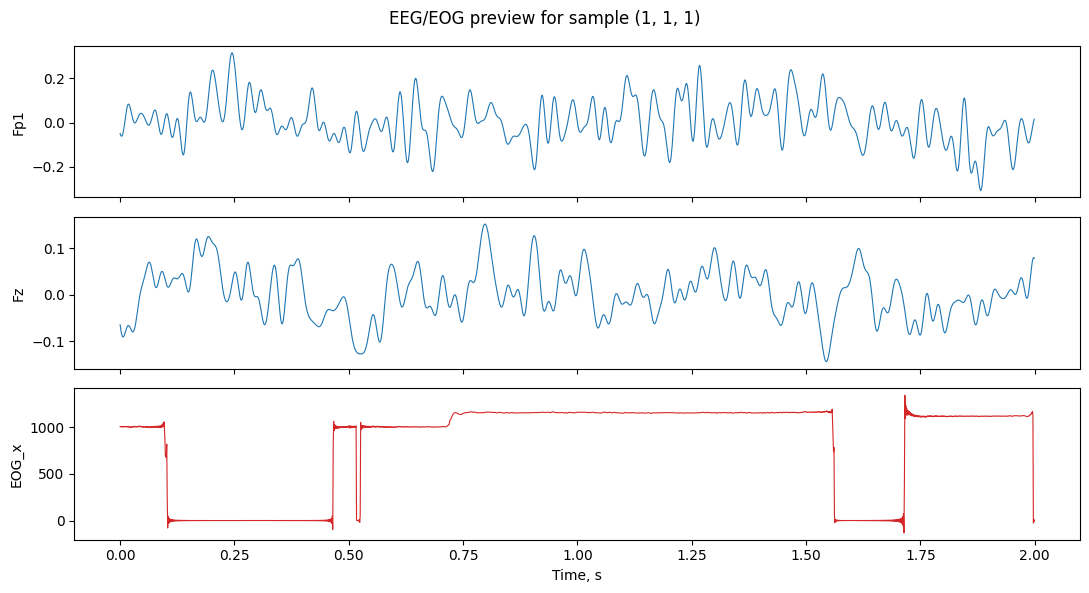

In [5]:
window_samples = min(int(2 * loaded.sfreq), loaded.eeg.shape[1])
time_seconds = np.arange(window_samples) / loaded.sfreq

figure, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for channel_index, axis in enumerate(axes[:2]):
    axis.plot(time_seconds, loaded.eeg[channel_index, :window_samples], linewidth=0.8)
    axis.set_ylabel(loaded.eeg_channels[channel_index])
axes[2].plot(time_seconds, loaded.eog[0, :window_samples], color="tab:red", linewidth=0.8)
axes[2].set_ylabel(loaded.eog_channels[0])
axes[2].set_xlabel("Time, s")
figure.suptitle(f"EEG/EOG preview for sample {sample_key}")
figure.tight_layout()
plt.show()

### 5. Фильтрация по типу паттерна

Фильтр применяется ко всем публичным индексам: `len`, integer key, tuple key и `source_map`.

In [6]:
geometric_dataset = NumpyDataset(DATASET_DIR, dataset_pattern_type="geometric", cache_policy=None)
random_dataset = NumpyDataset(DATASET_DIR, dataset_pattern_type="random", cache_policy=None)

filter_summary = pd.DataFrame(
    {
        "dataset": ["all", "geometric", "random"],
        "samples": [len(dataset), len(geometric_dataset), len(random_dataset)],
    }
)
display(filter_summary)

,dataset,samples
0,all,1260
1,geometric,840
2,random,420


### 6. Сравнить float32 и float64

Число отсчетов одинаково, но `float64` занимает вдвое больше памяти.

In [7]:
float64_dataset = NumpyDataset(DATASET_DIR, dtype=np.float64, cache_policy=None)
loaded_float64 = float64_dataset[sample_key]

dtype_comparison = pd.DataFrame(
    [
        {
            "dtype": str(item.eeg.dtype),
            "total_mib": (item.eeg.nbytes + item.eog.nbytes) / 2**20,
        }
        for item in (loaded, loaded_float64)
    ]
)
display(dtype_comparison)

,dtype,total_mib
0,float32,4.15065
1,float64,8.30130


## Checks

Фиксируем известные свойства реального `Data_Train`.

In [8]:
assert len(dataset) == 1260
assert len(geometric_dataset) == 840
assert len(random_dataset) == 420
assert loaded.eeg.shape == (63, 16001)
assert loaded.eog.shape == (5, 16001)
assert loaded.sfreq == 1000.0
assert loaded.eeg.dtype == np.float32
assert loaded_float64.eeg.dtype == np.float64
assert loaded_float64.eeg.nbytes == 2 * loaded.eeg.nbytes

pd.Series(
    {
        "dataset_size": "passed",
        "pattern_filter": "passed",
        "signal_shapes": "passed",
        "sampling_frequency": "passed",
        "dtype_conversion": "passed",
    },
    name="validation",
)

dataset_size          passed
pattern_filter        passed
signal_shapes         passed
sampling_frequency    passed
dtype_conversion      passed
Name: validation, dtype: str

## Next Steps

Сейчас повторный доступ снова читает FIF. Следующий этап добавит атомарный disk cache (`eeg.npy`, `eog.npy`, `manifest.json`) и проверяемую инвалидацию при изменении исходных файлов или dtype.